In [1]:
# 1. Import dependencies
import os
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, average_precision_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import ClassifierMixin
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
 
import warnings
warnings.filterwarnings("ignore")

# --- Wrappers add __sklearn_tags__ so VotingClassifier won’t crash under sklearn 1.2.2+ ---
class SklearnXGBClassifier(XGBClassifier, ClassifierMixin):
    def _more_tags(self):
        return {
            'estimator_type': 'classifier',
            'requires_fit': True,
            'binary_only': False,
            'multioutput': False,
            'allow_nan': True,
            'requires_y': True,
            'no_validation': False,
        }
    def __sklearn_tags__(self):
        return self._more_tags()

class SklearnLGBMClassifier(LGBMClassifier, ClassifierMixin):
    def _more_tags(self):
        return {
            'estimator_type': 'classifier',
            'requires_fit': True,
            'binary_only': False,
            'multioutput': False,
            'allow_nan': True,
            'requires_y': True,
            'no_validation': False,
        }
    def __sklearn_tags__(self):
        return self._more_tags()

In [2]:
# 2. Load & preprocess data
# Load Data
df = pd.read_csv("/kaggle/input/pipeline-creation/Churn-data-UCI Dataset(5000).csv")
print("Loaded shape:", df.shape)

df.columns = df.columns.str.strip().str.lower()
df["churn"] = df["churn"].astype(str).str.lower().str.strip().map({
    "yes": 1, "no": 0, "true": 1, "false": 0, "1": 1, "0": 0
})
df = df.dropna(subset=["churn"])

for col in df.columns:
    if df[col].dtype == "O":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

X = df.drop("churn", axis=1)
y = df["churn"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
RANDOM_STATE = 42
print("Scale_Pos_Weight for Imbalance:", round(scale_pos_weight, 2))

Loaded shape: (5000, 18)
Scale_Pos_Weight for Imbalance: 6.08


In [ ]:
# 3.1 Tuned Logistic Regression (Optuna)
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, f1_score
)
import numpy as np

# Predefined valid (solver, penalty) pairs
valid_combos = [
    ("liblinear", "l1"),
    ("liblinear", "l2"),
    ("saga", "l1"),
    ("saga", "l2"),
    ("saga", "elasticnet")
]

def objective_lr(trial):
    solver, penalty = trial.suggest_categorical("solver_penalty", valid_combos)
    C = trial.suggest_float("C", 1e-3, 100, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.1, 0.9) if penalty == "elasticnet" else None

    try:
        model = LogisticRegression(
            solver=solver,
            penalty=penalty,
            C=C,
            l1_ratio=l1_ratio,
            class_weight="balanced",  # ✅ Fix applied
            max_iter=5000,
            random_state=RANDOM_STATE
        )

        pipeline = make_pipeline(StandardScaler(), model)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        score = cross_val_score(pipeline, X_train, y_train, scoring="average_precision", cv=cv).mean()
        return score
    except Exception:
        raise optuna.exceptions.TrialPruned()

# Run Optuna optimization
study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=40)

# Extract best params and train final model
best_solver, best_penalty = study_lr.best_params["solver_penalty"]
best_params = {
    "solver": best_solver,
    "penalty": best_penalty,
    "C": study_lr.best_params["C"],
    "l1_ratio": study_lr.best_params.get("l1_ratio", None),
    "class_weight": "balanced",
    "max_iter": 5000,
    "random_state": RANDOM_STATE
}

final_lr = LogisticRegression(**best_params)
pipeline_lr = make_pipeline(StandardScaler(), final_lr)
pipeline_lr.fit(X_train, y_train)

print("✅ Best Parameters:", best_params)
print("✅ Best PR-AUC Score (CV):", study_lr.best_value)

# Threshold tuning: evaluate multiple thresholds
y_proba = pipeline_lr.predict_proba(X_test)[:, 1]
best_f1 = 0
best_threshold = 0.5

print("\n🔍 Threshold Tuning Report:")
for thresh in np.arange(0.2, 0.81, 0.05):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"Threshold: {thresh:.2f} | F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

# Final prediction using best threshold
y_pred_final = (y_proba >= best_threshold).astype(int)
print(f"\n✅ Best Threshold: {best_threshold:.2f} (F1: {best_f1:.4f})")

# ✅ Save model and threshold
joblib.dump(pipeline_lr, "tuned_logistic_regression_pipeline.pkl")
with open("lr_best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("\n💾 Model saved to: tuned_logistic_regression_pipeline.pkl")
print("💾 Threshold saved to: lr_best_threshold.txt")

In [ ]:
# 3.2 Tuned Extra Trees (Optuna)
import optuna
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score
import joblib  # ✅ for saving the model

# Assuming RANDOM_STATE, X_train, y_train are already defined
RANDOM_STATE = 42  # Adjust if needed

def objective_et(trial):
    model = ExtraTreesClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 5, 50),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    return cross_val_score(model, X_train, y_train, scoring="f1", cv=3).mean()

# Run Optuna optimization
study_et = optuna.create_study(direction="maximize")
study_et.optimize(objective_et, n_trials=40)

# Train final model with best parameters
best_et = ExtraTreesClassifier(
    **study_et.best_params,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
best_et.fit(X_train, y_train)

print("✅ Best Parameters for Extra Trees:", study_et.best_params)

# ✅ Save the model
joblib.dump(best_et, "tuned_extra_trees_model.pkl")
print("\n💾 Extra Trees model saved to: tuned_extra_trees_model.pkl")


In [ ]:
# 3.3 Tuned XGBoost (Optuna)
import optuna
import numpy as np
from xgboost import XGBClassifier as SklearnXGBClassifier
from sklearn.model_selection import cross_val_score
import joblib  # ✅ for saving the model

# Assuming RANDOM_STATE, scale_pos_weight, X_train, y_train are already defined
RANDOM_STATE = 42  # You can adjust if needed

def objective_xgb(trial):
    model = SklearnXGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0
    )
    return cross_val_score(model, X_train, y_train, scoring="f1", cv=3).mean()

# Run Optuna optimization
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=40)

# Train final model with best parameters
best_xgb = SklearnXGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    verbosity=0
)
best_xgb.fit(X_train, y_train)

print("✅ Best Parameters for XGBoost:", study_xgb.best_params)

# ✅ Save the model
joblib.dump(best_xgb, "tuned_xgboost_model.pkl")
print("\n💾 XGBoost model saved to: tuned_xgboost_model.pkl")


In [ ]:
# 3.4 Tuned CatBoost (Optuna)
import optuna
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import joblib  # ✅ for saving the model

# Assuming RANDOM_STATE, scale_pos_weight, X_train, y_train are already defined
RANDOM_STATE = 42  # Modify if needed

def objective_cb(trial):
    model = CatBoostClassifier(
        iterations=trial.suggest_int("iterations", 100, 1000),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        rsm=trial.suggest_float("rsm", 0.6, 1.0),
        border_count=trial.suggest_int("border_count", 32, 128),
        class_weights=[1.0, scale_pos_weight],
        eval_metric="F1",
        verbose=0,
        random_state=RANDOM_STATE
    )
    return cross_val_score(model, X_train, y_train, scoring="f1", cv=3).mean()

# Run Optuna optimization
study_cb = optuna.create_study(direction="maximize")
study_cb.optimize(objective_cb, n_trials=40)

# Train final model with best parameters
best_cb = CatBoostClassifier(
    **study_cb.best_params,
    class_weights=[1.0, scale_pos_weight],
    eval_metric="F1",
    verbose=0,
    random_state=RANDOM_STATE
)
best_cb.fit(X_train, y_train)

print("✅ Best Parameters for CatBoost:", study_cb.best_params)

# ✅ Save the model
joblib.dump(best_cb, "tuned_catboost_model.pkl")
print("\n💾 CatBoost model saved to: tuned_catboost_model.pkl")

In [ ]:
# 3.5 Tuned LightGBM (Optuna)
import optuna
import warnings
import numpy as np
from lightgbm import LGBMClassifier as SklearnLGBMClassifier
from sklearn.model_selection import cross_val_score
import joblib  # ✅ for saving the model

# Assuming RANDOM_STATE, X_train, y_train are already defined
RANDOM_STATE = 42  # Modify if needed

def objective_lgb(trial):
    model = SklearnLGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        num_leaves=trial.suggest_int("num_leaves", 20, 150),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 100),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
    return cross_val_score(model, X_train, y_train, scoring="f1", cv=3).mean()

# Run Optuna optimization
study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(objective_lgb, n_trials=40)

# Train final model with best parameters
best_lgbm = SklearnLGBMClassifier(
    **study_lgb.best_params,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

warnings.filterwarnings("ignore")
best_lgbm.fit(X_train, y_train)

print("✅ Best Parameters for LightGBM:", study_lgb.best_params)

# ✅ Save the model
joblib.dump(best_lgbm, "tuned_lightgbm_model.pkl")
print("\n💾 LightGBM model saved to: tuned_lightgbm_model.pkl")


In [ ]:
#4. Stacking model
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import joblib  # ✅ For saving the model

stack_with_lr = StackingClassifier(
    estimators=[
        ("lr", pipeline_lr),
        ("et", best_et),
        ("xgb", best_xgb),
        ("cb", best_cb),
        ("lgbm", best_lgbm)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

# Fit the stacking model
stack_with_lr.fit(X_train, y_train)

# ✅ Save the model
joblib.dump(stack_with_lr, "stacking_model_lr_final.pkl")
print("\n💾 Stacking model saved to: stacking_model_lr_final.pkl")


In [ ]:
# 5. Generating Meta-Feature Dataset
# Step 1: Utility function to extract class 1 probabilities
def get_proba(model, X, name):
    return pd.Series(model.predict_proba(X)[:, 1], name=name)

# Step 2: Generate meta-features for training set
train_meta = pd.concat([
    get_proba(pipeline_lr, X_train, 'LR'),
    get_proba(best_et, X_train, 'ET'),
    get_proba(best_xgb, X_train, 'XGB'),
    get_proba(best_cb, X_train, 'CB'),
    get_proba(best_lgbm, X_train, 'LGBM'),
    get_proba(stack_with_lr, X_train, 'STACK')
], axis=1)
train_meta['label'] = y_train.reset_index(drop=True)
train_meta['split'] = 'train'

# Step 3: Generate meta-features for test set
test_meta = pd.concat([
    get_proba(pipeline_lr, X_test, 'LR'),
    get_proba(best_et, X_test, 'ET'),
    get_proba(best_xgb, X_test, 'XGB'),
    get_proba(best_cb, X_test, 'CB'),
    get_proba(best_lgbm, X_test, 'LGBM'),
    get_proba(stack_with_lr, X_test, 'STACK')
], axis=1)
test_meta['label'] = y_test.reset_index(drop=True)
test_meta['split'] = 'test'

# Step 4: Combine and save
meta_df = pd.concat([train_meta, test_meta], axis=0).reset_index(drop=True)
meta_df.rename(columns={"label": "target"}, inplace=True)

# Step 5: Save to CSV
meta_df.to_csv("meta_features.csv", index=False)
print("✅ Saved as meta_features.csv")
meta_df.to_csv("meta_features.csv", index=False)

# Optional: View a few samples
display(meta_df.head())

In [ ]:
# 6.Shallow NN on Meta-Features 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import joblib  # ✅ For saving the model

# Load meta-feature dataset
meta_df = pd.read_csv("/kaggle/input/meta-feature-dataset/meta_features.csv")
X = meta_df.drop(columns=["target", "split"]).values
y = meta_df["target"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Shallow Neural Network using scikit-learn
mlp = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

# Save model ✅
joblib.dump(mlp, "shallow_nn_on_meta_features.pkl")
print("\n💾 Shallow NN model saved to: shallow_nn_on_meta_features.pkl")

# Predictions
y_pred = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Shallow NN)")
plt.show()

# Print metrics
print("Accuracy :", round(acc * 100, 2), "%")
print("Precision:", round(prec * 100, 2), "%")
print("Recall   :", round(rec * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")
print("PR-AUC   :", round(pr_auc * 100, 2), "%")


In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/pipeline-creation/Churn-data-UCI Dataset(5000).csv")
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())


In [ ]:
# 7. ChurnMetaPipeline Class
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder

class ChurnMetaPipeline:
    def __init__(self):
        # Load tuned and saved models
        self.lr = joblib.load("tuned_logistic_regression_pipeline.pkl")
        self.et = joblib.load("tuned_extra_trees_model.pkl")
        self.xgb = joblib.load("tuned_xgboost_model.pkl")
        self.cb = joblib.load("tuned_catboost_model.pkl")
        self.lgbm = joblib.load("tuned_lightgbm_model.pkl")
        self.stack = joblib.load("stacking_model_lr_final.pkl")
        self.meta_model = joblib.load("shallow_nn_on_meta_features.pkl")

        # Column order used during training (excluding churn)
        self.raw_columns = [
            'accountlength', 'internationalplan', 'voicemailplan', 'numbervmailmessages',
            'totaldayminutes', 'totaldaycalls', 'totaldaycharge', 'totaleveminutes',
            'totalevecalls', 'totalevecharge', 'totalnightminutes', 'totalnightcalls',
            'totalnightcharge', 'totalintlminutes', 'totalintlcalls', 'totalintlcharge',
            'numbercustomerservicecalls'
        ]

        # Placeholder for encoders
        self.label_encoders = {}

    def preprocess(self, raw_df):
        df = raw_df.copy()
        df.columns = df.columns.str.strip().str.lower()

        # Fill missing values
        for col in df.columns:
            if df[col].dtype == "O":
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].mean())

        # Encode categorical columns
        for col in df.select_dtypes(include="object").columns:
            if col not in self.label_encoders:
                le = LabelEncoder()
                le.fit(df[col])
                self.label_encoders[col] = le
            df[col] = self.label_encoders[col].transform(df[col])

        # Match training column order
        df = df[self.raw_columns]

        # Apply saved scaler inside the LR pipeline
        X_scaled = self.lr.named_steps['standardscaler'].transform(df)

        return X_scaled

    def predict(self, raw_df):
        X_proc = self.preprocess(raw_df)

        # Create meta-feature array
        meta_features = np.column_stack([
            self.lr.predict_proba(X_proc)[:, 1],
            self.et.predict_proba(X_proc)[:, 1],
            self.xgb.predict_proba(X_proc)[:, 1],
            self.cb.predict_proba(X_proc)[:, 1],
            self.lgbm.predict_proba(X_proc)[:, 1],
            self.stack.predict_proba(X_proc)[:, 1]
        ])

        return self.meta_model.predict(meta_features)

    def predict_proba(self, raw_df):
        X_proc = self.preprocess(raw_df)

        meta_features = np.column_stack([
            self.lr.predict_proba(X_proc)[:, 1],
            self.et.predict_proba(X_proc)[:, 1],
            self.xgb.predict_proba(X_proc)[:, 1],
            self.cb.predict_proba(X_proc)[:, 1],
            self.lgbm.predict_proba(X_proc)[:, 1],
            self.stack.predict_proba(X_proc)[:, 1]
        ])

        return self.meta_model.predict_proba(meta_features)


In [ ]:
# 8. Using the Pipeline for a New Customer Prediction
# Test on original dataset
df = pd.read_csv("/kaggle/input/pipeline-creation/Churn-data-UCI Dataset(5000).csv")

# Clean & preprocess like you did before
df.columns = df.columns.str.strip().str.lower()
df["churn"] = df["churn"].astype(str).str.lower().str.strip().map({
    "yes": 1, "no": 0, "true": 1, "false": 0, "1": 1, "0": 0
})
df = df.dropna(subset=["churn"])

for col in df.columns:
    if df[col].dtype == "O":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Drop target column to keep only features
X_raw = df.drop("churn", axis=1)

# ✅ Pick a random customer from original raw dataset
new_customer = pd.DataFrame([X_raw.sample(random_state=42).iloc[0]])

# ✅ Use your prediction pipeline
pipeline = ChurnMetaPipeline()
result = pipeline.predict(new_customer)

print("✅ Final Churn Prediction (0 = No, 1 = Yes):", result[0])
proba = pipeline.predict_proba(new_customer)[0][1]  # Probability of churning
print(f"📊 Churn Probability: {proba:.2%}")



100%|===================| 3733/3750 [01:50<00:00]        

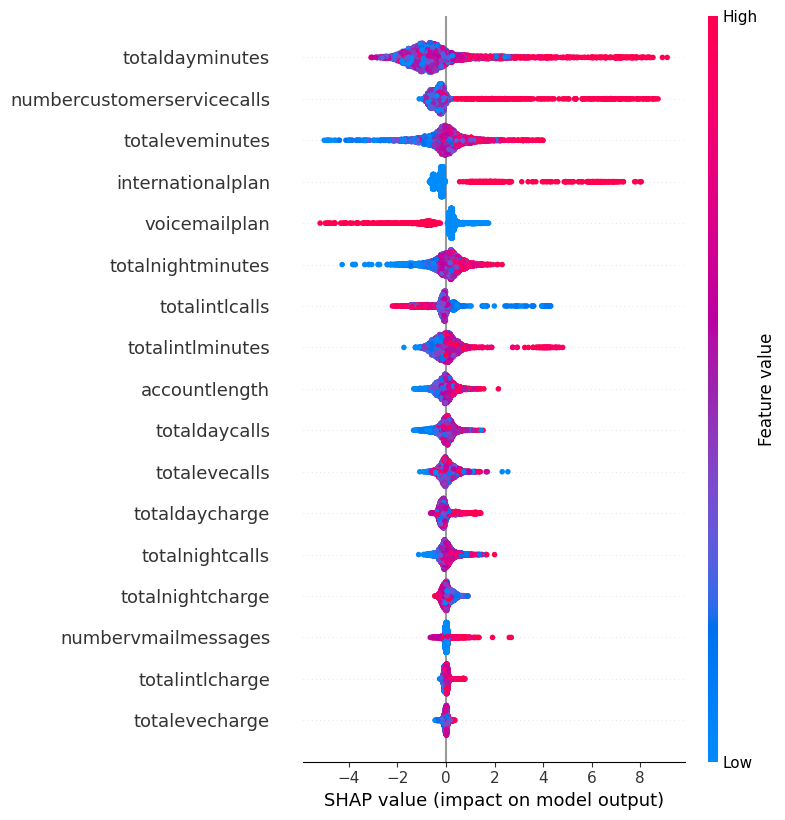

In [4]:
# 9.1 SHAP Summary Dot Plot for XGBoost
import shap
import joblib

# Load the trained XGBoost model
xgb_model = joblib.load("/kaggle/input/saved-models/tuned_xgboost_model.pkl")

# Convert X_train to float
X_train_numeric = X_train.astype(float)

# Explain
explainer = shap.Explainer(xgb_model, X_train_numeric)
shap_values = explainer(X_train_numeric)

# Plot
shap.summary_plot(shap_values, X_train_numeric)


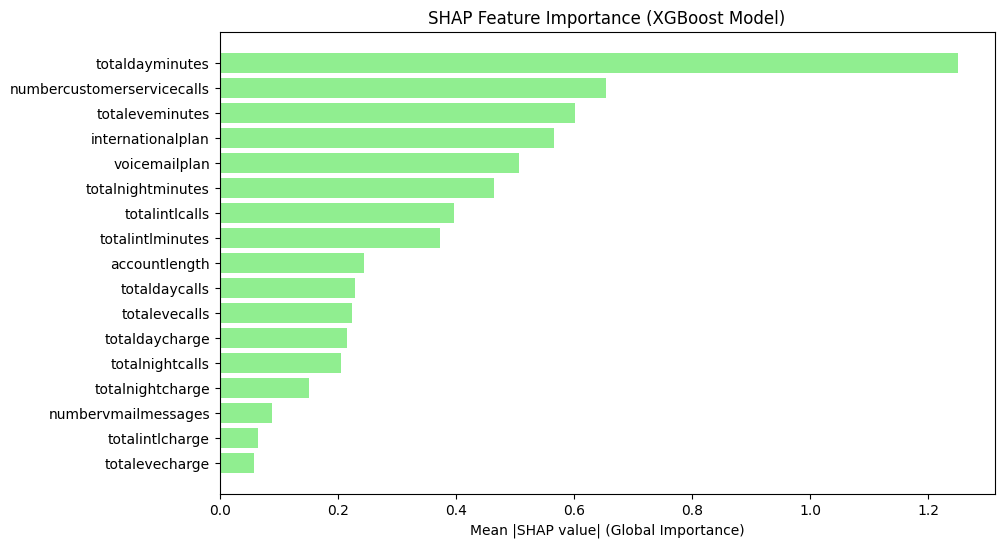

In [5]:
# 9.2 SHAP Bar Plot (Global Feature Importance)
# Get mean absolute SHAP values
shap_values_abs_mean = np.abs(shap_values.values).mean(axis=0)

# Create bar plot manually
plt.figure(figsize=(10, 6))
shap_order = np.argsort(shap_values_abs_mean)[::-1]  # Sort descending
feature_names = X_train.columns[shap_order]
shap_scores = shap_values_abs_mean[shap_order]

plt.barh(feature_names, shap_scores, color='lightgreen')
plt.xlabel("Mean |SHAP value| (Global Importance)")
plt.title("SHAP Feature Importance (XGBoost Model)")
plt.gca().invert_yaxis()
plt.show()



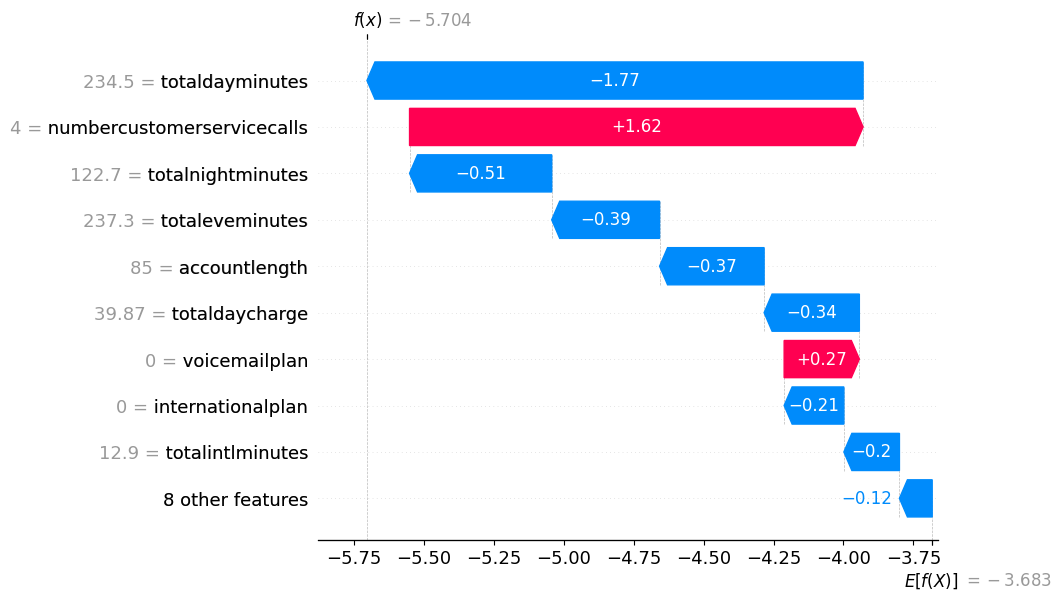

In [6]:
# 9.3 SHAP Waterfall Plot for a Single Customer (XGBoost)
sample_index = 0  # You can change to try other rows

shap.plots.waterfall(shap_values[sample_index], max_display=10)


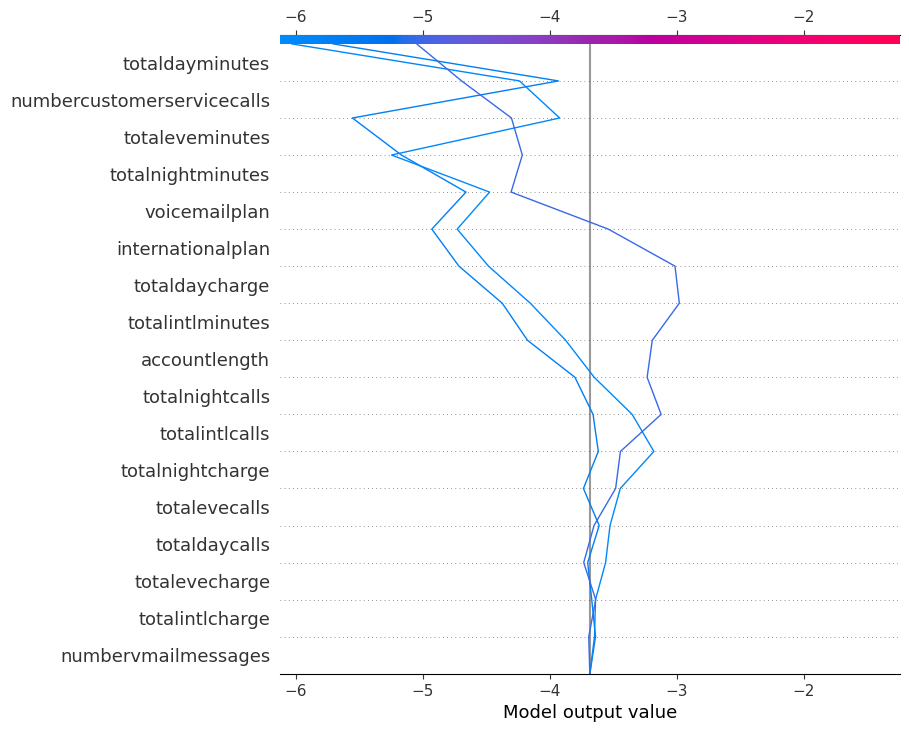

In [9]:
# 9.4 SHAP Decision Plot for One or More Customers (XGBoost)
shap.decision_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values.values[:3],   # Take first 3 samples
    features=X_train_numeric.iloc[:3],
    feature_names=X_train.columns.tolist()
)

In [10]:
# 10.1 LIME Explanation (HTML Plot) for XGBoost
import lime
import lime.lime_tabular

# Ensure input is numeric
X_train_np = X_train_numeric.to_numpy()
feature_names = X_train.columns.tolist()
class_names = ['No Churn', 'Churn']

# Create Lime Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True
)

# Pick one sample
sample_row = X_train_np[0].reshape(1, -1)

# Predict using XGB model
lime_exp = lime_explainer.explain_instance(
    data_row=X_train_np[0],
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

# Show as HTML
lime_exp.show_in_notebook(show_table=True)


In [11]:
# 10.2 LIME Rule-Based Explanation (Text Only)
# Show explanation in plain text
print(lime_exp.as_list())


[('internationalplan <= 0.00', -0.4440725287252719), ('totaldayminutes > 215.90', 0.23685763742540095), ('numbercustomerservicecalls > 2.00', 0.14153975736671537), ('voicemailplan <= 0.00', 0.09437950911882263), ('totaleveminutes > 233.80', 0.07324829270517058), ('totalintlcalls <= 3.00', 0.0663179985179837), ('totalintlminutes > 12.10', 0.0399759255709156), ('totalnightminutes <= 166.40', -0.03724792361541304), ('73.00 < accountlength <= 100.00', -0.02675142957848212), ('numbervmailmessages <= 0.00', 0.022011483693897584)]


In [13]:
!pip install -q alibi

In [15]:
# 11.1 Anchor Explanation for XGBoost (Tabular)

from alibi.explainers import AnchorTabular
import numpy as np

# Convert data to NumPy
X_train_np = X_train_numeric.to_numpy()
feature_names = X_train.columns.tolist()
class_names = ['No Churn', 'Churn']

# Initialize Anchor explainer
anchor_explainer = AnchorTabular(predictor=xgb_model.predict, feature_names=feature_names)
anchor_explainer.fit(X_train_np, disc_perc=(25, 50, 75))

# Choose a customer to explain
sample_index = 0
sample_instance = X_train_np[sample_index]

# Generate explanation
anchor_exp = anchor_explainer.explain(sample_instance)

# Print explanation
print(f"🔍 Anchor Rule:\n{anchor_exp.anchor}")
print(f"\n📝 Precision: {anchor_exp.precision:.2f}")
print(f"📊 Coverage: {anchor_exp.coverage:.2f}")


🔍 Anchor Rule:
['totaldaycharge > 24.43', 'internationalplan <= 0.00', 'totalnightcharge <= 7.49', 'totaldaycalls <= 114.00', 'accountlength <= 126.00', 'totalnightcalls > 87.00']

📝 Precision: 0.95
📊 Coverage: 0.07


In [17]:
import pandas as pd

# Load your meta-feature file
meta_df = pd.read_csv("/kaggle/input/meta-feature-dataset/meta_features.csv")
print("📋 Columns in meta feature dataset:\n", meta_df.columns.tolist())


📋 Columns in meta feature dataset:
 ['LR', 'ET', 'XGB', 'CB', 'LGBM', 'STACK', 'target', 'split']


In [22]:
# 11.2 Anchor Explanation for Meta Model (MLPClassifier)

from alibi.explainers import AnchorTabular
import numpy as np

# Load meta-feature dataset
meta_df = pd.read_csv("/kaggle/input/meta-feature-dataset/meta_features.csv")

# ✅ Only keep the exact columns used to train MLPClassifier
used_columns = ['LR', 'ET', 'XGB', 'CB', 'LGBM', 'STACK']
X_meta = meta_df[used_columns]
X_meta_np = X_meta.to_numpy()

# Load MLPClassifier
import joblib
mlp_model = joblib.load("/kaggle/input/saved-models/shallow_nn_on_meta_features.pkl")  # Adjust if needed

# Anchor for meta model
from alibi.explainers import AnchorTabular
anchor_explainer_meta = AnchorTabular(predictor=mlp_model.predict, feature_names=used_columns)
anchor_explainer_meta.fit(X_meta_np, disc_perc=(25, 50, 75))

# Explain 1 row
sample_instance = X_meta_np[0]
anchor_exp_meta = anchor_explainer_meta.explain(sample_instance)

# Result
print(f"🔍 Anchor Rule for Meta Model:\n{anchor_exp_meta.anchor}")
print(f"\n📝 Precision: {anchor_exp_meta.precision:.2f}")
print(f"📊 Coverage: {anchor_exp_meta.coverage:.2f}")

🔍 Anchor Rule for Meta Model:
['XGB <= 0.00', 'LGBM <= 0.03']

📝 Precision: 1.00
📊 Coverage: 0.48


In [24]:
# 12.1 Real-Time Inference Pipeline
import pandas as pd
import joblib
import numpy as np

# Load all 6 models
lr = joblib.load("/kaggle/input/saved-models/tuned_logistic_regression_pipeline.pkl")
et = joblib.load("/kaggle/input/saved-models/tuned_extra_trees_model.pkl")
xgb = joblib.load("/kaggle/input/saved-models/tuned_xgboost_model.pkl")
cb = joblib.load("/kaggle/input/saved-models/tuned_catboost_model.pkl")
lgbm = joblib.load("/kaggle/input/saved-models/tuned_lightgbm_model.pkl")
stack = joblib.load("/kaggle/input/saved-models/stacking_model_lr_final.pkl")
mlp = joblib.load("/kaggle/input/saved-models/shallow_nn_on_meta_features.pkl")

# Feature columns used during training (must match)
raw_columns = ['accountlength', 'internationalplan', 'voicemailplan', 'numbervmailmessages',
               'totaldayminutes', 'totaldaycalls', 'totaldaycharge', 'totaleveminutes',
               'totalevecalls', 'totalevecharge', 'totalnightminutes', 'totalnightcalls',
               'totalnightcharge', 'totalintlminutes', 'totalintlcalls', 'totalintlcharge',
               'numbercustomerservicecalls']

categorical_columns = ['internationalplan', 'voicemailplan']

# Helper function to preprocess one row
def preprocess_one_row(row_df):
    # Encode categorical values
    row_df = row_df.copy()
    for col in categorical_columns:
        row_df[col] = row_df[col].map({'yes': 1, 'no': 0}).fillna(0)
    row_df = row_df[raw_columns]
    return row_df

# Final function to predict one customer's churn
def predict_churn_real_time(customer_row_df):
    row = preprocess_one_row(customer_row_df)

    # Get meta-features from base and stack models
    meta_row = pd.DataFrame([{
        "LR": lr.predict_proba(row)[0][1],
        "ET": et.predict_proba(row)[0][1],
        "XGB": xgb.predict_proba(row)[0][1],
        "CB": cb.predict_proba(row)[0][1],
        "LGBM": lgbm.predict_proba(row)[0][1],
        "STACK": stack.predict_proba(row)[0][1],
    }])

    # Predict using MLP classifier
    pred = mlp.predict(meta_row)[0]
    proba = mlp.predict_proba(meta_row)[0][1]

    print("✅ Real-time Prediction for this customer:")
    print("Final Prediction:", "Churn" if pred == 1 else "No Churn")
    print(f"Churn Probability: {proba:.2%}")


In [25]:
# 12.2 Example new customer
new_customer = pd.DataFrame([{
    'accountlength': 128,
    'internationalplan': 'no',
    'voicemailplan': 'yes',
    'numbervmailmessages': 25,
    'totaldayminutes': 265.1,
    'totaldaycalls': 110,
    'totaldaycharge': 45.07,
    'totaleveminutes': 197.4,
    'totalevecalls': 99,
    'totalevecharge': 16.78,
    'totalnightminutes': 244.7,
    'totalnightcalls': 91,
    'totalnightcharge': 11.01,
    'totalintlminutes': 10.0,
    'totalintlcalls': 3,
    'totalintlcharge': 2.7,
    'numbercustomerservicecalls': 1
}])

predict_churn_real_time(new_customer)


✅ Real-time Prediction for this customer:
Final Prediction: No Churn
Churn Probability: 0.51%
